version 5.3
## Set environment

## Global Variables

These variables are generally pre-defined and should only be reviewed to ensure correctness.  
They control the input and output paths used throughout the pipeline.

---

### Required Files

The following files are required for this analysis:

- `Vx.cohort.snp.final.vcf.gz`
- `Vx.cohort.snp.final.vcf.gz.tbi`

These files were provided by the author as part of a reanalysis of data from the following publication:  
[https://doi.org/10.1111/tpj.13501](https://doi.org/10.1111/tpj.13501)

Please **cite this publication** if you use the accompanying code or data.


Example of **"PoolSample.tsv"**
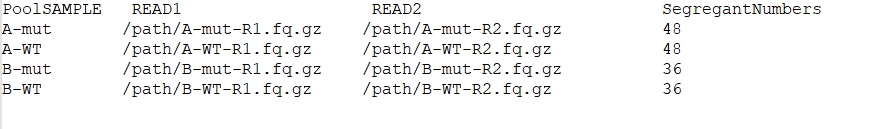

In [ ]:
#!/bin/bash
#SBATCH -J PoolSeq
#SBATCH -p bio
#SBATCH -c 8
#SBATCH --output=%A_%a.out
#SBATCH --error=%A_%a.err

source /Share/samples/Acluster.sh
source /Share/home/chenhaodonglab/dengzg1993/bin/DZG_env.sh

############################
# Paths
############################

WORKDIR=$(pwd)

REF_FASTA=/Data/ChenhaodongLab/Data_deposited/Reference_genome/Physcomitrella/Gd_v6.1/Ppatens_870_V6.fasta
SNP_SITES=/Share/home/dengzg1993/Analyses/DNASeq/Physcomitrella/1.WGS/05.Villersexel/2024.11.25_v6.1/4.annotate/Results/Vx.cohort.snp.final.vcf.gz

TMPDIR=/Share/home/dengzg1993/tmp

SampleInfo=$WORKDIR/PoolSample.tsv
dos2unix $SampleInfo

############################
# Array index
############################

TASK_ID=${SLURM_ARRAY_TASK_ID:-1}

LINE_MUT=$((TASK_ID*2))
LINE_WT=$((TASK_ID*2+1))

read SAMPLE_MUT READ1_MUT READ2_MUT PLOIDY_MUT \
< <(awk -v line=$LINE_MUT 'NR==line {print $1,$2,$3,$4}' $SampleInfo)

read SAMPLE_WT READ1_WT READ2_WT PLOIDY_WT \
< <(awk -v line=$LINE_WT 'NR==line {print $1,$2,$3,$4}' $SampleInfo)

BASE_SAMPLE=${SAMPLE_MUT%%-*}

OUTDIR=$WORKDIR/${BASE_SAMPLE}-pool

mkdir -p \
$OUTDIR/report \
$OUTDIR/1.mapping \
$OUTDIR/2.variants \
$OUTDIR/3.output \
$OUTDIR/4.result

############################
# Logging
############################

log(){
echo "[$(date '+%F %T')] $1"
}

log "Start sample $BASE_SAMPLE"

############################
# Genome size
############################

GENOME_SIZE=$(grep -v ">" $REF_FASTA | wc -c)

############################
# Depth estimation (sampling)
############################

estimate_depth(){

sample=$1
read1=$2
resultvar=$3

NUM_READS=$(zcat $read1 | head -n 4000000 | wc -l)
NUM_READS=$((NUM_READS/4))

DEPTH=$(echo "$NUM_READS * 150 * 2 / $GENOME_SIZE" | bc)

eval $resultvar=$DEPTH

}

estimate_depth $SAMPLE_MUT $READ1_MUT DEPTH_MUT
estimate_depth $SAMPLE_WT $READ1_WT DEPTH_WT

############################
# FastQC
############################

log "FastQC"

fastqc -o $OUTDIR/report --noextract $READ1_MUT $READ2_MUT &> $OUTDIR/report/fastqc_mut.log &
fastqc -o $OUTDIR/report --noextract $READ1_WT $READ2_WT &> $OUTDIR/report/fastqc_wt.log &

wait

############################
# Mapping
############################

map_sample(){

sample=$1
r1=$2
r2=$3

log "Mapping $sample"

bwa mem -t 4 -M \
-R "@RG\tID:$sample\tSM:$sample\tPL:ILLUMINA" \
$REF_FASTA $r1 $r2 |
samtools sort -@ 2 -o $OUTDIR/1.mapping/$sample.sorted.bam -

picard MarkDuplicates \
-I $OUTDIR/1.mapping/$sample.sorted.bam \
-O $OUTDIR/1.mapping/$sample.dedup.bam \
-M $OUTDIR/1.mapping/$sample.metrics.txt \
--TMP_DIR $TMPDIR

samtools index $OUTDIR/1.mapping/$sample.dedup.bam

}

map_sample $SAMPLE_MUT $READ1_MUT $READ2_MUT &
map_sample $SAMPLE_WT  $READ1_WT  $READ2_WT  &

wait

############################
# HaplotypeCaller
############################

call_gvcf(){

sample=$1
ploidy=$2

gatk HaplotypeCaller \
-R $REF_FASTA \
-I $OUTDIR/1.mapping/$sample.dedup.bam \
--intervals $SNP_SITES \
--sample-ploidy $ploidy \
-ERC GVCF \
-O $OUTDIR/2.variants/$sample.g.vcf.gz

}

call_gvcf $SAMPLE_MUT $PLOIDY_MUT &
call_gvcf $SAMPLE_WT $PLOIDY_WT &

wait

############################
# Merge GVCF
############################

log "Combine GVCF"

gatk CombineGVCFs \
-R $REF_FASTA \
--variant $OUTDIR/2.variants/$SAMPLE_MUT.g.vcf.gz \
--variant $OUTDIR/2.variants/$SAMPLE_WT.g.vcf.gz \
-O $OUTDIR/2.variants/$BASE_SAMPLE.Combine.g.vcf.gz

############################
# Chromosome list
############################

grep ">" $REF_FASTA | sed 's/>//' | cut -d ' ' -f1 > $OUTDIR/chr.list

############################
# Parallel Genotype
############################

MAX_JOBS=8

while read CHR
do

gatk --java-options "-Xmx4G" GenotypeGVCFs \
-R $REF_FASTA \
-V $OUTDIR/2.variants/$BASE_SAMPLE.Combine.g.vcf.gz \
-L $CHR \
-O $OUTDIR/3.output/$BASE_SAMPLE.Combine.$CHR.vcf.gz &

while [ $(jobs -r | wc -l) -ge $MAX_JOBS ]
do
sleep 2
done

done < $OUTDIR/chr.list

wait

############################
# Merge VCF
############################

log "Merge VCF"

gatk MergeVcfs \
$(for f in $OUTDIR/3.output/*.vcf.gz; do echo "-I $f"; done) \
-O $OUTDIR/4.result/$BASE_SAMPLE.Combine.vcf.gz

############################
# Filtering
############################

gatk VariantFiltration \
-R $REF_FASTA \
-V $OUTDIR/4.result/$BASE_SAMPLE.Combine.vcf.gz \
-O $OUTDIR/4.result/$BASE_SAMPLE.Combine.filter.vcf.gz \
-filter-name "hard_filter" \
-filter "QD < 2.0 || SOR > 3.0 || FS > 60.0 || MQ < 40.0"

gatk SelectVariants --exclude-filtered --select-type-to-include SNP \
    --restrict-alleles-to BIALLELIC \
    -select "vc.getGenotype('$SAMPLE_MUT').getDP() > 0.3 * $DEPTH_MUT" \
    -select "vc.getGenotype('$SAMPLE_MUT').getDP() < 3 * $DEPTH_MUT" \
    -select "vc.getGenotype('$SAMPLE_WT').getDP() > 0.3 * $DEPTH_WT" \
    -select "vc.getGenotype('$SAMPLE_WT').getDP() < 3 * $DEPTH_WT" \
    -V $OUTDIR/4.result/$BASE_SAMPLE.Combine.filter.vcf.gz \
    -O $OUTDIR/4.result/$BASE_SAMPLE.Combine.snp.cleaned.vcf.gz

############################
# Export allele depth
############################

gatk VariantsToTable \
-V $OUTDIR/4.result/$BASE_SAMPLE.Combine.snp.cleaned.vcf.gz \
-F CHROM -F POS -GF AD \
-O $OUTDIR/4.result/$BASE_SAMPLE.Combine.results_var_AD.table

log "Finished $BASE_SAMPLE"